<!--Copyright 2026 The HuggingFace Team. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
-->

# Fine-tuning LFM2-VL-450M on a tiny dataset (with loss & before/after visualization)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/lfm2_vl_finetuning.ipynb)

[LFM2-VL-450M](https://huggingface.co/LiquidAI/LFM2-VL-450M) is the smallest of Liquid AI's first vision-language foundation models. It pairs a **350M LFM2** language backbone with an **86M SigLIP2 NaFlex** vision encoder and a pixel-unshuffle MLP connector. At ~450M parameters it is light enough to run in a web browser (WebGPU) — and small enough to **LoRA fine-tune on a single small GPU (or even CPU) with fewer than 50 images**.

In this notebook we:

1. Load `LFM2-VL-450M` with `AutoModelForImageTextToText`.
2. Build a tiny (< 50 image) synthetic dataset that is **diverse on purpose** — **40 colors**, **12 shapes** (2D + pseudo-3D cube/sphere/cylinder/cone/pyramid), and **five spatial relations** (inside / left / right / above / below). Each image is essentially unique, so the model cannot just memorize a handful of labels.
3. Record the model's **baseline** answers *before* fine-tuning.
4. Fine-tune with **LoRA + TRL's `SFTTrainer`**, capturing the loss at every step.
5. **Visualize the training loss curve** and **compare before/after predictions on the images**.

## 1. Setup

Install the dependencies. On Colab, restart the runtime if prompted after the install.

In [ ]:
%pip install -q -U transformers trl peft datasets accelerate pillow matplotlib torchvision

In [2]:
%matplotlib inline
import math
import random

import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw

from transformers import AutoModelForImageTextToText, AutoProcessor

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print('Using device:', device, '| dtype:', dtype)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu | dtype: torch.float32


## 2. Load the model and processor

In [3]:
model_id = 'LiquidAI/LFM2-VL-450M'
processor = AutoProcessor.from_pretrained(model_id)
if processor.tokenizer.pad_token_id is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded {model_id} with {n_params / 1e6:.0f}M parameters')

Loaded LiquidAI/LFM2-VL-450M with 451M parameters


## 3. Build a tiny but diverse dataset (< 50 images)

Every record is a dict `{image, question, answer}`:

- **`image`** + **`question`** are the model's **input**.
- **`answer`** is the **ground-truth label** — the text we train the model to produce. It is *not* an input.

We draw the images with Pillow (no download). The dataset spans **40 colors** and **12 shapes** (2D: circle, square, triangle, diamond, pentagon, hexagon, star; pseudo-3D: cube, sphere, cylinder, cone, pyramid) over six task types:

| task | example question | example answer |
| --- | --- | --- |
| single | *What colored shape is in this image?* | `red star` |
| inside | *Where is the red circle relative to the blue star?* | `the red circle is inside the blue star` |
| left / right | *Where is the green cube relative to the gold sphere?* | `the green cube is to the left of the gold sphere` |
| above / below | *Where is the teal cone relative to the pink cube?* | `the teal cone is above the pink cube` |

The spatial question always names **both** shapes, so the relation (left vs. right, above vs. below) is unambiguous.

In [4]:
COLORS = {
    'red': (220, 50, 50), 'green': (40, 170, 80), 'blue': (60, 90, 220), 'yellow': (240, 200, 40),
    'orange': (240, 140, 30), 'purple': (150, 60, 200), 'cyan': (40, 190, 200), 'pink': (240, 120, 180),
    'magenta': (200, 40, 160), 'lime': (140, 210, 40), 'teal': (20, 140, 140), 'navy': (30, 40, 120),
    'maroon': (130, 30, 40), 'olive': (120, 120, 30), 'brown': (140, 80, 40), 'gold': (212, 175, 55),
    'salmon': (240, 130, 110), 'coral': (240, 110, 80), 'crimson': (200, 20, 60), 'indigo': (75, 0, 130),
    'violet': (180, 90, 220), 'turquoise': (50, 200, 170), 'tan': (190, 150, 100), 'khaki': (180, 170, 90),
    'plum': (160, 90, 150), 'orchid': (190, 90, 180), 'chocolate': (160, 90, 40), 'tomato': (240, 90, 60),
    'sienna': (140, 80, 50), 'slateblue': (95, 95, 205), 'steelblue': (70, 120, 170), 'skyblue': (95, 170, 220),
    'seagreen': (40, 140, 95), 'forestgreen': (30, 115, 50), 'hotpink': (240, 100, 170), 'deeppink': (220, 40, 120),
    'mustard': (210, 170, 40), 'mint': (90, 205, 150), 'lavender': (170, 150, 225), 'rose': (220, 90, 130),
}
SHAPES_2D = ['circle', 'square', 'triangle', 'diamond', 'pentagon', 'hexagon', 'star']
SHAPES_3D = ['cube', 'sphere', 'cylinder', 'cone', 'pyramid']
SHAPES = SHAPES_2D + SHAPES_3D
print(len(COLORS), 'colors x', len(SHAPES), 'shapes')


def shade(rgb, f):
    return tuple(max(0, min(255, int(c * f))) for c in rgb)


def ngon(n, cx, cy, r, rot=-math.pi / 2):
    return [(cx + r * math.cos(rot + 2 * math.pi * i / n), cy + r * math.sin(rot + 2 * math.pi * i / n))
            for i in range(n)]


def star_pts(cx, cy, r):
    pts = []
    for i in range(10):
        rad = r if i % 2 == 0 else r * 0.45
        ang = math.pi * i / 5 - math.pi / 2
        pts.append((cx + rad * math.cos(ang), cy + rad * math.sin(ang)))
    return pts


def draw_shape(draw, shape, color, cx, cy, r):
    rgb = COLORS[color]
    if shape == 'circle':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == 'square':
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == 'triangle':
        draw.polygon([(cx, cy - r), (cx - r * 0.92, cy + r * 0.8), (cx + r * 0.92, cy + r * 0.8)], fill=rgb)
    elif shape == 'diamond':
        draw.polygon([(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)], fill=rgb)
    elif shape == 'pentagon':
        draw.polygon(ngon(5, cx, cy, r), fill=rgb)
    elif shape == 'hexagon':
        draw.polygon(ngon(6, cx, cy, r), fill=rgb)
    elif shape == 'star':
        draw.polygon(star_pts(cx, cy, r), fill=rgb)
    elif shape == 'cube':
        draw.polygon([(cx - r, cy - r / 2), (cx, cy), (cx, cy + r), (cx - r, cy + r / 2)], fill=shade(rgb, 0.6))
        draw.polygon([(cx, cy), (cx + r, cy - r / 2), (cx + r, cy + r / 2), (cx, cy + r)], fill=shade(rgb, 0.85))
        draw.polygon([(cx, cy - r), (cx + r, cy - r / 2), (cx, cy), (cx - r, cy - r / 2)], fill=shade(rgb, 1.2))
    elif shape == 'sphere':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=shade(rgb, 0.8))
        for i in range(7):
            t = i / 7
            rr = r * (1 - t) * 0.85
            ox, oy = cx - r * 0.28, cy - r * 0.28
            draw.ellipse([ox - rr, oy - rr, ox + rr, oy + rr], fill=shade(rgb, 0.8 + 0.55 * t))
    elif shape == 'cylinder':
        eh = r * 0.32
        draw.ellipse([cx - r, cy + r - eh, cx + r, cy + r + eh], fill=shade(rgb, 0.65))
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=shade(rgb, 0.85))
        draw.ellipse([cx - r, cy - r - eh, cx + r, cy - r + eh], fill=shade(rgb, 1.15))
    elif shape == 'cone':
        eh = r * 0.32
        draw.ellipse([cx - r, cy + r - eh, cx + r, cy + r + eh], fill=shade(rgb, 0.65))
        draw.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=shade(rgb, 0.95))
    elif shape == 'pyramid':
        apex, front = (cx, cy - r), (cx, cy + r)
        draw.polygon([apex, (cx - r, cy + r * 0.35), front], fill=shade(rgb, 0.7))
        draw.polygon([apex, front, (cx + r, cy + r * 0.35)], fill=shade(rgb, 1.0))
    else:
        raise ValueError(shape)

40 colors x 12 shapes


In [5]:
def canvas(size=256):
    return Image.new('RGB', (size, size), 'white')


def render_single(color, shape, size=256):
    img = canvas(size)
    draw_shape(ImageDraw.Draw(img), shape, color, size // 2, size // 2, size // 3)
    return img


def render_inside(c_out, s_out, c_in, s_in, size=256):
    img = canvas(size)
    d = ImageDraw.Draw(img)
    draw_shape(d, s_out, c_out, size // 2, size // 2, size // 2 - 14)
    draw_shape(d, s_in, c_in, size // 2, size // 2, size // 7)
    return img


def render_pair(c1, s1, c2, s2, axis, size=256):
    img = canvas(size)
    d = ImageDraw.Draw(img)
    r = size // 7
    if axis == 'h':
        draw_shape(d, s1, c1, size // 4, size // 2, r)
        draw_shape(d, s2, c2, 3 * size // 4, size // 2, r)
    else:
        draw_shape(d, s1, c1, size // 2, size // 4, r)
        draw_shape(d, s2, c2, size // 2, 3 * size // 4, r)
    return img


Q_SINGLE = "What colored shape is in this image? Answer with '<color> <shape>'."
Q_SPATIAL = 'Where is the {a} located relative to the {b}? Describe the spatial relationship.'


def spatial_record(image, c1, s1, c2, s2, relation):
    return {'image': image,
            'question': Q_SPATIAL.format(a=f'{c1} {s1}', b=f'{c2} {s2}'),
            'answer': f'the {c1} {s1} is {relation} the {c2} {s2}'}

In [6]:
MAX_SAMPLES = 40  # keep it under 50
rng = random.Random(SEED)

n_single = round(MAX_SAMPLES * 0.4)
n_inside = round(MAX_SAMPLES * 0.15)
n_horiz = round(MAX_SAMPLES * 0.225)
n_vert = MAX_SAMPLES - n_single - n_inside - n_horiz

records = []
single_combos = [(c, s) for c in COLORS for s in SHAPES]
rng.shuffle(single_combos)
for c, s in single_combos[:n_single]:
    records.append({'image': render_single(c, s), 'question': Q_SINGLE, 'answer': f'{c} {s}'})

for _ in range(n_inside):
    c_out, c_in = rng.sample(list(COLORS), 2)
    s_out, s_in = rng.sample(SHAPES_2D, 2)
    records.append(spatial_record(render_inside(c_out, s_out, c_in, s_in), c_in, s_in, c_out, s_out, 'inside'))

for _ in range(n_horiz):
    c1, c2 = rng.sample(list(COLORS), 2)
    s1, s2 = rng.sample(SHAPES, 2)
    img = render_pair(c1, s1, c2, s2, 'h')
    if rng.random() < 0.5:
        records.append(spatial_record(img, c1, s1, c2, s2, 'to the left of'))
    else:
        records.append(spatial_record(img, c2, s2, c1, s1, 'to the right of'))

for _ in range(n_vert):
    c1, c2 = rng.sample(list(COLORS), 2)
    s1, s2 = rng.sample(SHAPES, 2)
    img = render_pair(c1, s1, c2, s2, 'v')
    if rng.random() < 0.5:
        records.append(spatial_record(img, c1, s1, c2, s2, 'above'))
    else:
        records.append(spatial_record(img, c2, s2, c1, s1, 'below'))

rng.shuffle(records)
print(f'Built {len(records)} images: {n_single} single, {n_inside} inside, {n_horiz} left/right, {n_vert} above/below')

Built 40 images: 16 single, 6 inside, 9 left/right, 9 above/below


Let's look at a sample of the dataset (image + its ground-truth `answer`):

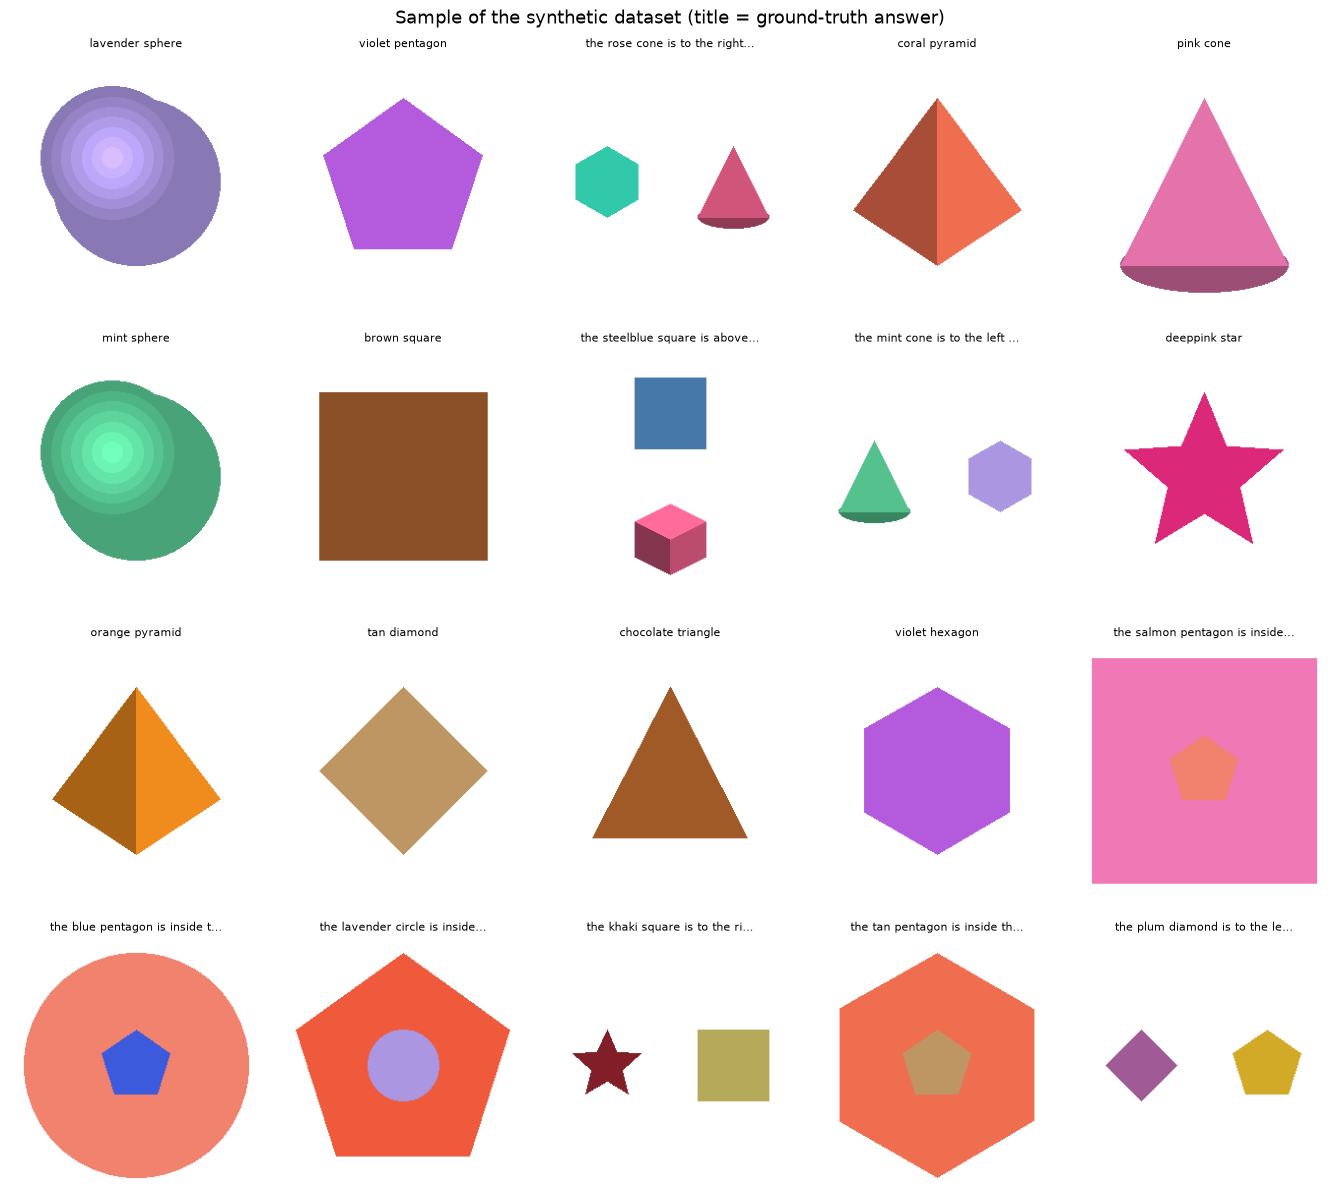

In [7]:
def clip(text, n=30):
    return text if len(text) <= n else text[:n - 1] + '\u2026'


show = records[:20]
cols = 5
rows = (len(show) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2.7 * cols, 3.1 * rows))
for ax, rec in zip(axes.flat, show):
    ax.imshow(rec['image'])
    ax.set_title(clip(rec['answer']), fontsize=8)
    ax.axis('off')
for ax in axes.flat[len(show):]:
    ax.axis('off')
fig.suptitle('Sample of the synthetic dataset (title = ground-truth answer)', fontsize=13)
plt.tight_layout()
plt.show()

Format each record into an LFM2-VL chat conversation (a `user` turn with the image + question, and an `assistant` turn with the answer).

In [8]:
def to_conversation(record):
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': record['image']},
                {'type': 'text', 'text': record['question']},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': record['answer']}]},
        ]
    }


train_dataset = [to_conversation(r) for r in records]

## 4. Inference helper

A helper that feeds the image + question to the model, plus a normalized match (ignoring articles/punctuation) to score predictions against the ground-truth answer.

In [9]:
@torch.no_grad()
def predict(model, record, max_new_tokens=28):
    conversation = [{'role': 'user', 'content': [
        {'type': 'image', 'image': record['image']},
        {'type': 'text', 'text': record['question']},
    ]}]
    inputs = processor.apply_chat_template(
        conversation, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors='pt',
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()


STOP = {'a', 'an', 'the', 'to', 'of', 'is', 'there'}


def normalize(text):
    return [w for w in text.lower().replace(',', ' ').replace('.', ' ').split() if w not in STOP]


def is_correct(pred, target):
    t = normalize(target)
    return normalize(pred)[:len(t)] == t

## 5. Baseline predictions (before fine-tuning)

In [10]:
model.eval()
before_preds = [predict(model, rec) for rec in records]
before_acc = sum(is_correct(p, r['answer']) for p, r in zip(before_preds, records)) / len(records)
for rec, pred in zip(records[:12], before_preds[:12]):
    print(f"gt={rec['answer'][:46]:<46} before={pred!r}")
print(f'\nbaseline accuracy: {before_acc:.0%}')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


gt=lavender sphere                                before='The image contains a purple circle.'
gt=violet pentagon                                before='purple pentagon'
gt=the rose cone is to the right of the turquoise before='The rose cone is located to the right of the turquoise hexagon. The spatial relationship is such that the rose cone is positioned slightly'
gt=coral pyramid                                  before='The image contains a red diamond.'
gt=pink cone                                      before='The image contains a pink cone.'
gt=mint sphere                                    before='The image contains a green circle.'
gt=brown square                                   before='brown'
gt=the steelblue square is above the rose cube    before='The steelblue square is located above and to the left of the rose cube. The spatial relationship shows that the steelblue square is positioned higher'
gt=the mint cone is to the left of the lavender h before='The mint cone is locat

## 6. LoRA fine-tuning with TRL `SFTTrainer`

LoRA adapters on the attention + MLP projections, trained with TRL's `SFTTrainer`. A `TrainerCallback` records the loss (and token accuracy) at every step. The collator tokenizes a batch with the chat template and masks **pad tokens** and the **`<image>` placeholder tokens** so the loss is only computed on real answer text.

In [11]:
from peft import LoraConfig
from transformers import TrainerCallback
from trl import SFTConfig, SFTTrainer

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj', 'gate_proj', 'up_proj', 'down_proj'],
    task_type='CAUSAL_LM',
)

pad_token_id = processor.tokenizer.pad_token_id
image_token_id = processor.image_token_id


def collate_fn(examples):
    batch = processor.apply_chat_template(
        [ex['messages'] for ex in examples],
        add_generation_prompt=False, tokenize=True,
        return_dict=True, return_tensors='pt', padding=True,
    )
    labels = batch['input_ids'].clone()
    labels[labels == pad_token_id] = -100
    labels[labels == image_token_id] = -100
    batch['labels'] = labels
    return batch


class LossHistory(TrainerCallback):
    def __init__(self):
        self.steps, self.loss, self.acc = [], [], []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.steps.append(state.global_step)
            self.loss.append(logs['loss'])
            self.acc.append(logs.get('mean_token_accuracy'))


history = LossHistory()

In [12]:
sft_config = SFTConfig(
    output_dir='./lfm2-vl-450m-lora',
    num_train_epochs=12,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    max_length=1024,
    logging_steps=1,
    bf16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
    remove_unused_columns=False,
    dataset_kwargs={'skip_prepare_dataset': True},
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    peft_config=peft_config,
    processing_class=processor.tokenizer,
    callbacks=[history],
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 7, 'bos_token_id': 1, 'pad_token_id': 0}.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Step,Training Loss
1,6.152501
2,7.884806
3,4.621927
4,5.196522
5,7.112993
6,6.496421
7,4.034359
8,3.947158
9,4.229641
10,5.257187


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


...

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


TrainOutput(global_step=480, training_loss=0.41881528448623917, metrics={'train_runtime': 1295.6617, 'train_samples_per_second': 0.37, 'train_steps_per_second': 0.37, 'total_flos': 114306712289280.0, 'train_loss': 0.41881528448623917})

## 7. Visualize the training loss

The loss should fall steadily while token accuracy climbs toward 1.0.

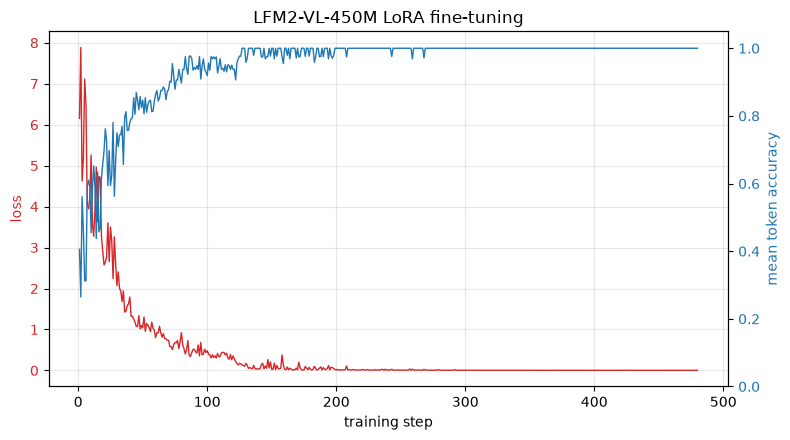

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(history.steps, history.loss, color='tab:red', lw=1, label='loss')
ax1.set_xlabel('training step')
ax1.set_ylabel('loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(alpha=0.3)

if any(a is not None for a in history.acc):
    ax2 = ax1.twinx()
    ax2.plot(history.steps, history.acc, color='tab:blue', lw=1, label='token accuracy')
    ax2.set_ylabel('mean token accuracy', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, 1.05)

plt.title('LFM2-VL-450M LoRA fine-tuning')
fig.tight_layout()
plt.show()

## 8. Predictions after fine-tuning

In [14]:
trainer.model.eval()
after_preds = [predict(trainer.model, rec) for rec in records]
after_acc = sum(is_correct(p, r['answer']) for p, r in zip(after_preds, records)) / len(records)
for rec, pred in zip(records[:12], after_preds[:12]):
    print(f"gt={rec['answer'][:46]:<46} after={pred!r}")
print(f'\naccuracy: {before_acc:.0%} -> {after_acc:.0%}')

gt=lavender sphere                                after='lavender sphere'
gt=violet pentagon                                after='violet pentagon'
gt=the rose cone is to the right of the turquoise after='the rose cone is to the right of the turquoise hexagon'
gt=coral pyramid                                  after='coral pyramid'
gt=pink cone                                      after='pink cone'
gt=mint sphere                                    after='mint sphere'
gt=brown square                                   after='brown square'
gt=the steelblue square is above the rose cube    after='the steelblue square is above the rose cube'
gt=the mint cone is to the left of the lavender h after='the mint cone is to the left of the lavender hexagon'
gt=deeppink star                                  after='deeppink star'
gt=orange pyramid                                 after='orange pyramid'
gt=tan diamond                                    after='tan diamond'

accuracy: 0% -> 100%


## 9. Before vs. after — visual comparison

Each panel shows, for one image, the **ground-truth answer (gt)** and the model's prediction **before** (red if wrong) and **after** (green if correct) fine-tuning. Remember the model's actual input is the image **plus the question** (e.g. *"Where is the red circle relative to the blue star?"*) — only the answers are shown here.

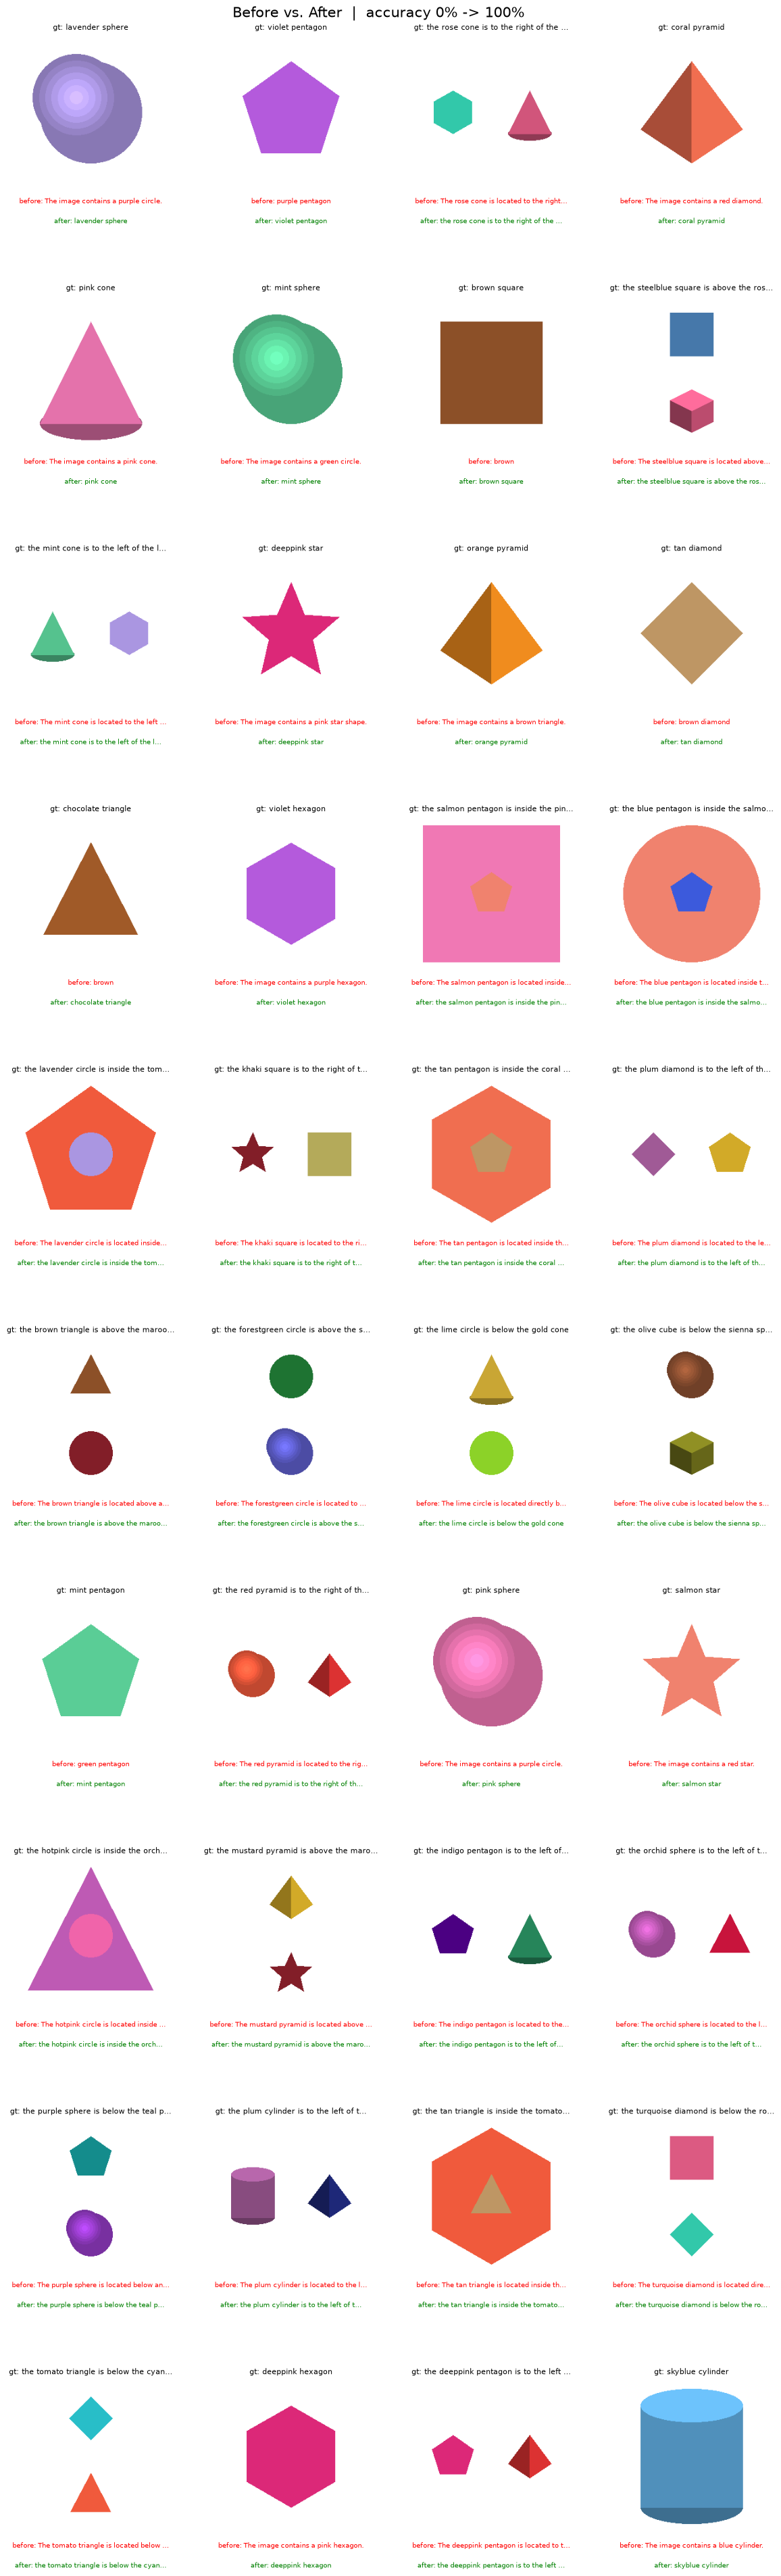

In [15]:
cols = 4
rows = (len(records) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.7 * cols, 4.3 * rows))
for ax, rec, before, after in zip(axes.flat, records, before_preds, after_preds):
    ax.imshow(rec['image'])
    ax.axis('off')
    b_color = 'green' if is_correct(before, rec['answer']) else 'red'
    a_color = 'green' if is_correct(after, rec['answer']) else 'red'
    ax.set_title(f"gt: {clip(rec['answer'], 38)}", fontsize=8)
    ax.text(0.5, -0.06, f'before: {clip(before, 38)}', color=b_color, fontsize=7.5,
            ha='center', va='top', transform=ax.transAxes)
    ax.text(0.5, -0.19, f'after: {clip(after, 38)}', color=a_color, fontsize=7.5,
            ha='center', va='top', transform=ax.transAxes)
for ax in axes.flat[len(records):]:
    ax.axis('off')

fig.suptitle(f'Before vs. After  |  accuracy {before_acc:.0%} -> {after_acc:.0%}', fontsize=15)
plt.subplots_adjust(hspace=0.7, wspace=0.15, top=0.97)
plt.show()

## 10. Save and reload the adapter

The LoRA adapter is only a few MB. Save it alongside the processor, then reload on top of the base model.

In [16]:
trainer.save_model('./lfm2-vl-450m-lora')
processor.save_pretrained('./lfm2-vl-450m-lora')

# Reload later with:
# from peft import PeftModel
# base = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype)
# tuned = PeftModel.from_pretrained(base, './lfm2-vl-450m-lora')
# tuned = tuned.merge_and_unload()  # optional: fold LoRA into the base weights
print('Saved adapter + processor to ./lfm2-vl-450m-lora')

Saved adapter + processor to ./lfm2-vl-450m-lora


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


## Next steps

- Swap the synthetic data for your own images — keep the `{image, question, answer}` shape and everything else works unchanged.
- The 100%-style numbers here are *training-set* accuracy on a memorization-resistant dataset. To measure true **generalization**, hold out some (color, shape, relation) combinations and evaluate only on the unseen ones.
- To fine-tune on a real Hub dataset (e.g. [`HuggingFaceH4/llava-instruct-mix-vsft`](https://huggingface.co/datasets/HuggingFaceH4/llava-instruct-mix-vsft)), load a small slice with `datasets.load_dataset(name, split='train[:40]')` and map it into the same conversation format.

**References**: [Liquid AI blog](https://www.liquid.ai/blog/lfm2-vl-efficient-vision-language-models) · [LFM2-VL-450M model card](https://huggingface.co/LiquidAI/LFM2-VL-450M) · [LFM2-VL TRL guide](https://docs.liquid.ai/customization/finetuning-frameworks/trl)